In [1]:
# Install the ART library (provides adversarial attacks)
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.7 MB/s eta 0:00:00


In [2]:
# Import libraries
import tensorflow
import numpy as np
import matplotlib.pyplot as plt
import os
from os import listdir
import cv2
import natsort
from sklearn.model_selection import train_test_split

# Print the version of tensorflow
print("TensorFlow version:{}".format(tensorflow.__version__))

TensorFlow version:2.19.0


In [3]:
# Download the dataset
!wget https://www.idahofallshighered.org/vakanski/Codes_Data/Vehicles.zip

--2026-01-17 02:00:02--  https://www.idahofallshighered.org/vakanski/Codes_Data/Vehicles.zip
Resolving www.idahofallshighered.org (www.idahofallshighered.org)... 50.6.2.30
Connecting to www.idahofallshighered.org (www.idahofallshighered.org)|50.6.2.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 866542025 (826M) [application/zip]
Saving to: ‘Vehicles.zip’

Vehicles.zip        100%[===================>] 826.40M  14.2MB/s    in 59s     

2026-01-17 02:01:01 (14.1 MB/s) - ‘Vehicles.zip’ saved [866542025/866542025]



In [4]:
# Uncompress the dataset
!unzip -uq 'Vehicles.zip' -d 'sample_data/'

In [5]:
# Function to load the images and the labels from the dataset
def load_images_and_labels(directory):

    imgs_list = []
    labels_list = []

    # List of all subfolders in the directory
    subfolders_list_1 = listdir(directory)
    # Make sure that the subfolders are sorted
    subfolders_list = natsort.natsorted(subfolders_list_1)

    # Assign a label to each folder with images (0 to the first folder)
    lab = 0
    for subfolder_name in subfolders_list:
            sub_dir_path = directory + '/' + subfolder_name

            # Read the images as numpy arrays
            imagesList = listdir(sub_dir_path)
            for i in range(len(imagesList)):
              tmp_img = cv2.imread(os.path.join(sub_dir_path, imagesList[i]))
              # Resize all images to 128 x 128 pixels
              resized_img = cv2.resize(tmp_img, (128, 128))
              img_arr = np.array(resized_img)
              imgs_list.append(img_arr/255.)
              labels_list.append(lab)
            lab += 1

    # Convert the lists to numpy arrays
    imgs = np.asarray(imgs_list)
    labels = np.asarray(labels_list)

    return imgs, labels

# Use the above function to load the dataset
images, labels = load_images_and_labels('sample_data/Vehicles')

In [6]:
# Split the dataset into train and test sets
train_and_val_images, test_images, train_and_val_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=12)

In [7]:
# Split the train dataset into training and validation sets
train_images, val_images, train_labels, val_labels = train_test_split(train_and_val_images, train_and_val_labels, test_size=0.2, random_state=12)

In [8]:
# Display the shapes of train, validation, and test datasets
print('Images train shape: {} - Labels train shape: {}'.format(train_images.shape, train_labels.shape))
print('Images validation shape: {} - Labels validation shape: {}'.format(val_images.shape, val_labels.shape))
print('Images test shape: {} - Labels test shape: {}'.format(test_images.shape, test_labels.shape))

# Display the range of images (to make sure they are in the [0, 1] range)
print('\nMax pixel value', np.max(train_images))
print('Min pixel value', np.min(train_images))
print('Average pixel value', np.mean(train_images))
print('Data type', train_images[0].dtype)

Images train shape: (3577, 128, 128, 3) - Labels train shape: (3577,)
Images validation shape: (895, 128, 128, 3) - Labels validation shape: (895,)
Images test shape: (1118, 128, 128, 3) - Labels test shape: (1118,)

Max pixel value 1.0
Min pixel value 0.0
Average pixel value 0.5120286736626715
Data type float64


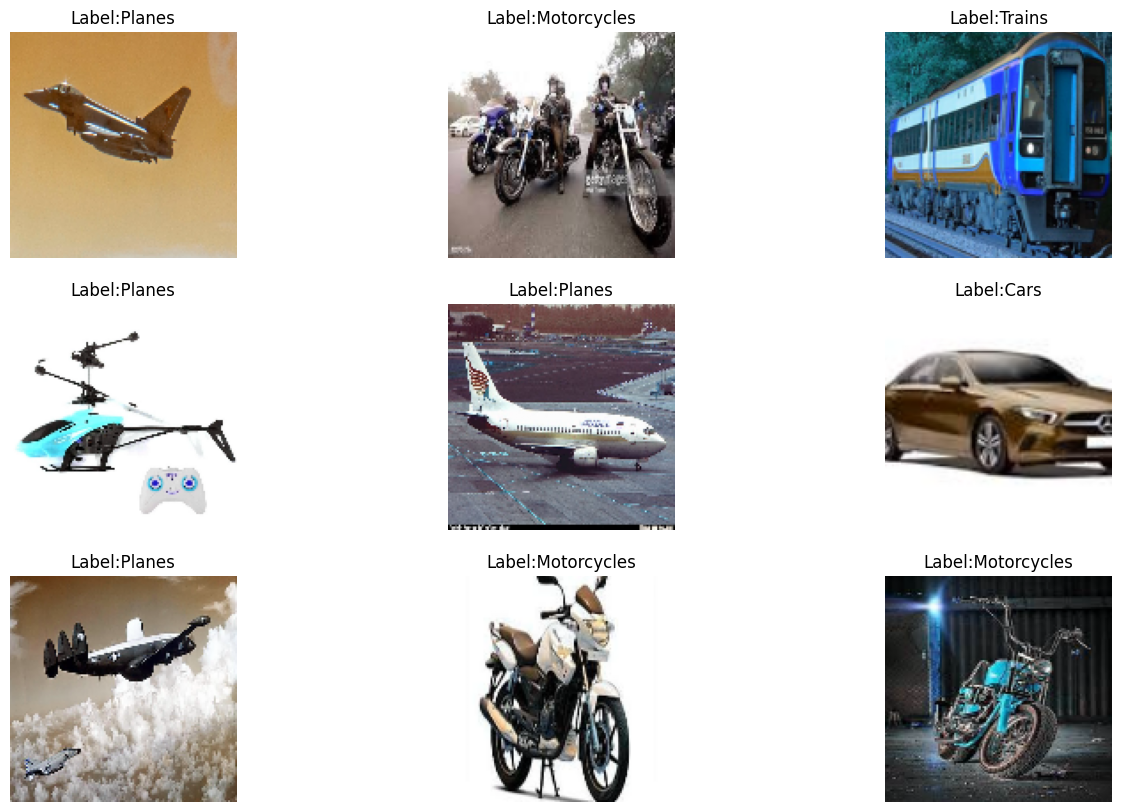

In [9]:
# A list with the names of the image classes
label_names = ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']

# Plot a few images to check if the labels make sense
plt.figure(figsize=(16, 10))
for n in range(9):
    i = np.random.randint(0, len(train_images), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(train_images[i[0]])
    plt.title('Label:' + str(label_names[train_labels[i[0]]]))
    plt.axis('off')

In [ ]:
# Your code here

In [ ]:
# Your code here

In [ ]:
# Your code here